# Beginner's Approach to Titanic Dataset Analysis. Upvote if you like it! 

Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from sklearn import metrics
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

Reading

In [2]:
train = pd.read_csv("../input/titanic/train.csv")
test = pd.read_csv("../input/titanic/test.csv")
submission = test[["PassengerId"]]

Exploring

In [3]:
train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [4]:
train = train.drop_duplicates()

In [5]:
print("______TRAIN_______")
print(train.info())
print("______TEST________")
print(test.info())

______TRAIN_______
<class 'pandas.core.frame.DataFrame'>
Int64Index: 891 entries, 0 to 890
Data columns (total 12 columns):
PassengerId    891 non-null int64
Survived       891 non-null int64
Pclass         891 non-null int64
Name           891 non-null object
Sex            891 non-null object
Age            714 non-null float64
SibSp          891 non-null int64
Parch          891 non-null int64
Ticket         891 non-null object
Fare           891 non-null float64
Cabin          204 non-null object
Embarked       889 non-null object
dtypes: float64(2), int64(5), object(5)
memory usage: 90.5+ KB
None
______TEST________
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
PassengerId    418 non-null int64
Pclass         418 non-null int64
Name           418 non-null object
Sex            418 non-null object
Age            332 non-null float64
SibSp          418 non-null int64
Parch          418 non-null int64
Ticket         418 non-nu

Cleaning Data 
* PassengerID may be dropped.
* Pclass may be made string.
* Title may be extracted from Name and then Name may be dropped.
* Age may be rounded.
* Cabin may be dropped.

In [6]:
def clean1(df):
    
    Title = []
    for name in df["Name"]:
        if "Mr." in name:
            Title.append("Mr")
        elif "Mrs." in name:
            Title.append("Mrs")
        elif "Miss." in name:
            Title.append("Miss")
        elif "Master." in name:
            Title.append("Master")
        elif "Rev." in name:
            Title.append("Rev")
        elif "Don." in name:
            Title.append("Don")
        elif "Dr." in name:
            Title.append("Dr")
        elif "Mme." in name:
            Title.append("Miss")
        elif "Ms." in name:
            Title.append("Mrs")
        elif "Major." in name:
            Title.append("Major")
        elif "Mrs" in name:
            Title.append("Mrs")
        elif "Mr" in name:
            Title.append("Mr")
        elif "Mlle." in name:
            Title.append("Miss")
        elif "Col." in name:
            Title.append("Col")
        elif "Capt." in name:
            Title.append("Capt")
        elif "Countess." in name:
            Title.append("Countess")
        elif "Jonkheer." in name:
            Title.append("Jonkheer")
        else:
            Title.append("Other")
            
    df["Title"] = Title
    
    df = df.astype({
        "Pclass" : str,
    })

    df["Age"] = round(df["Age"])
    
    df = df.drop(columns = ["PassengerId", "Name", "Cabin"])
    
    return df

In [7]:
train = clean1(train)
test = clean1(test)

In [8]:
print("______TRAIN_______")
print(train.isnull().sum())
print("______TEST________")
print(test.isnull().sum())

______TRAIN_______
Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Embarked      2
Title         0
dtype: int64
______TEST________
Pclass       0
Sex          0
Age         86
SibSp        0
Parch        0
Ticket       0
Fare         1
Embarked     0
Title        0
dtype: int64


Cleaning Data
* Age, Embarked and Fair may be filled using some patterns

In [9]:
train[train["Embarked"].isnull()]
# pd.crosstab(train["Embarked"], train["Survived"])
# pd.crosstab(train["Embarked"], train["Pclass"])
# pd.crosstab(train["Embarked"], train["Title"])

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title
61,1,1,female,38.0,0,0,113572,80.0,NaN,Miss
829,1,1,female,62.0,0,0,113572,80.0,NaN,Mrs


Embarked is likely "S" for both

In [10]:
ind = train[train["Embarked"].isnull()].index
train.loc[ind, "Embarked"] = "S"

In [11]:
test[test["Fare"].isnull()]

,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title
152,3,male,60.0,0,0,3701,NaN,S,Mr


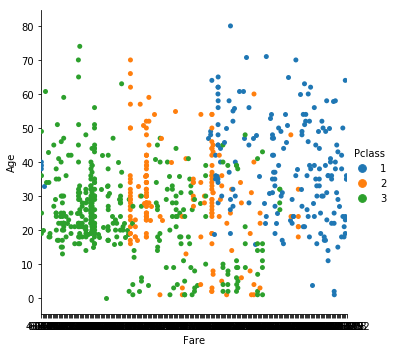

In [12]:
sns.catplot(x = "Fare", y = "Age", hue = "Pclass", data = train)

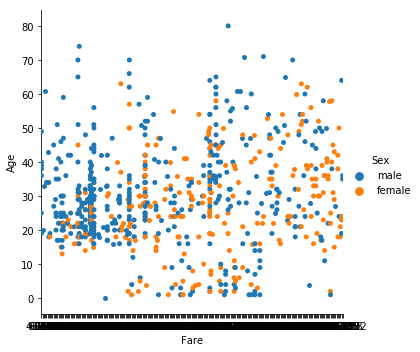

In [13]:
sns.catplot(x = "Fare", y = "Age", hue = "Sex", data = train)

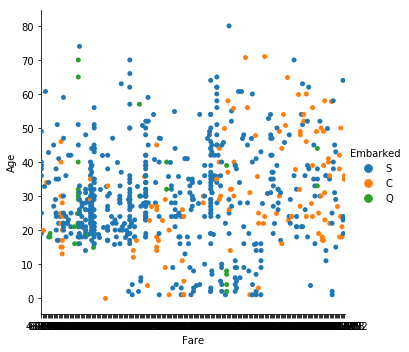

In [14]:
sns.catplot(x = "Fare", y = "Age", hue = "Embarked", data = train)

We may take Fare = average Fare of passengers with:
1. 45<Age<75
2. Sex = male
3. Pclass = 3
4. Embarked = S

In [15]:
fare = np.nanmean(train["Fare"][
    (train["Age"] > 45) & (train["Age"] < 75) & 
    (train["Sex"] == "male") & 
    (train["Pclass"] == "3") &
    (train["Embarked"] == "S")
])
ind = test[test["Fare"].isnull()].index
test.loc[ind, "Fare"] = fare

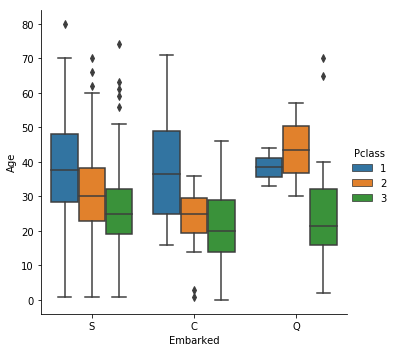

In [16]:
sns.catplot(x = "Embarked", y = "Age", hue = "Pclass", kind = "box", data = train)

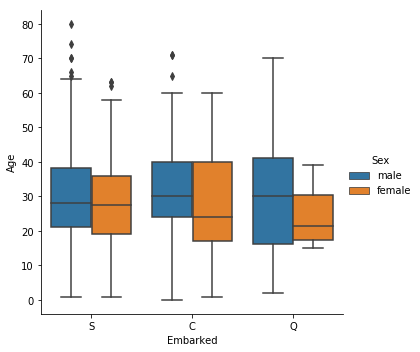

In [17]:
sns.catplot(x = "Embarked", y = "Age", hue = "Sex", kind = "box", data = train)

We may take Age = median Age of passengers with same:
1. Embarked
2. Pclass
3. Sex

In [18]:
def clean2(df, train):
    ind = df[df["Age"].isnull()].index
    for i in ind:
        emb = df.loc[i]["Embarked"]
        pc = df.loc[i]["Pclass"]
        sex = df.loc[i]["Sex"]
        
        age = np.nanmedian(train["Age"][(train["Embarked"] == emb) & (train["Pclass"] == pc) & (train["Sex"] == sex)])
        df.loc[i, "Age"] = age

    return(df)

In [19]:
train = clean2(train, train)
test = clean2(test, train)

Clean Data
* Sex may be one-hot encoded.
* Embarked may be one-hot & frequency encoded.
* Ticket may be frequency encoded.
* Title may be frequency encoded.
* Pclass may be one-hot & frequency encoded.

In [20]:
cols = ["Sex", "Embarked", "Pclass"]
    
train_temp = train[cols]
train_ind = train_temp.index
    
test_temp = test[cols]
test_ind = test_temp.index
    
enc = OneHotEncoder(drop = "first")
# To avoid multi-collinearlty (dummy variable trap) due to one-hot-encoding, use drop = "first"
enc.fit(train_temp)
        
train_hot = enc.transform(train_temp).toarray()
train_hot = pd.DataFrame(train_hot, columns = enc.get_feature_names(cols), index = train_ind)
train = train.drop(columns = ["Sex"])
train = pd.concat([train, train_hot], axis = 1)
    
test_hot = enc.transform(test_temp).toarray()
test_hot = pd.DataFrame(test_hot, columns = enc.get_feature_names(cols), index = test_ind)
test = test.drop(columns = ["Sex"])
test = pd.concat([test, test_hot], axis = 1)

In [21]:
def GetFreqMap(train_data):
    cols = ["Embarked", "Ticket", "Title", "Pclass"]
    MyMap = {}
    for col in cols:
        temp = {}
        temp = train_data[col].value_counts()/train_data.shape[0]
        temp = defaultdict(lambda : 0, temp)
        MyMap[col] = temp
    
    return MyMap 

In [22]:
def GetMeanMap(train_data):
    cols = ["Embarked", "Ticket", "Title", "Pclass"]
    MyMap = {}
    for col in cols:
        temp = {}
        categories = train_data[col].value_counts().keys()
        for cat in categories:
            n1 = train_data[col][(train_data[col] == cat) & (train_data["Survived"] == 1)].shape[0]
            n2 = train_data[col][(train_data[col] == cat)].shape[0]
            temp[cat] = n1/n2
        
        temp = defaultdict(lambda : 0, temp)
        MyMap[col] = temp
        
    return MyMap

In [23]:
def MapMe(df, FM, MM):
    temp_freq = pd.DataFrame()
    temp_mean = pd.DataFrame()
    
    cols = ["Embarked", "Ticket", "Title", "Pclass"]
    for col in cols:
        temp_freq[col + "_freq"] = df[col].map(FM[col])
        temp_mean[col + "_mean"] = df[col].map(MM[col])
        
    df = pd.concat([df, temp_freq, temp_mean], axis = 1)
    df = df.drop(columns = ["Embarked", "Ticket", "Title", "Pclass"])
    
    return df

In [24]:
FM = GetFreqMap(train)
MM = GetMeanMap(train)
train = MapMe(train, FM, MM)
test = MapMe(test, FM, MM)

In [25]:
train_data = train.loc[:, train.columns != "Survived"]
train_labels = train[["Survived"]]
test_data = test

# scaler = MinMaxScaler()
# scaler.fit(train_data)
# cols = train_data.columns

# train_ind = train_data.index
# train_data = scaler.transform(train_data)
# train_data = pd.DataFrame(train_data, columns = cols, index = train_ind)

# test_ind = test_data.index
# test_data = scaler.transform(test_data)
# test_data = pd.DataFrame(test_data, columns = cols, index = test_ind) 

Clean Data
* Check for collinearity

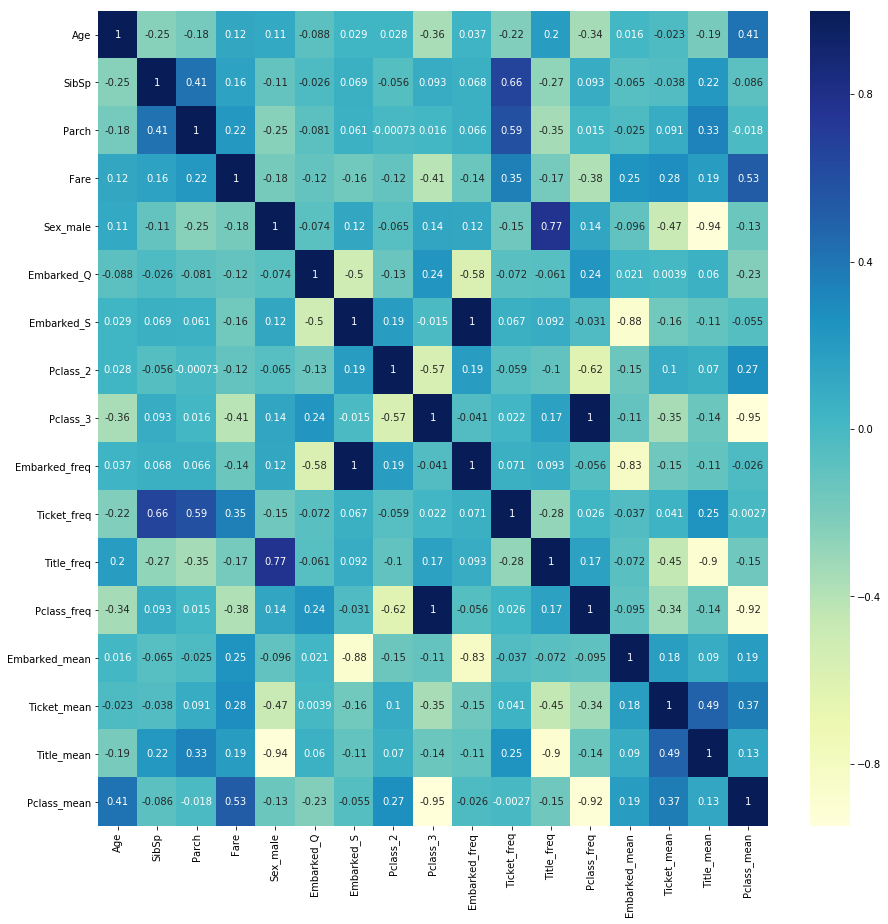

In [26]:
plt.figure(figsize = (15, 15))
sns.heatmap(train_data.corr(), cmap = "YlGnBu", annot = True)

Removing Pclass_3 and Embarked_S

In [27]:
train_data = train_data.drop(columns = ["Pclass_3", "Embarked_S"])
test_data = test_data.drop(columns = ["Pclass_3", "Embarked_S"])

Modeling

In [28]:
def ModelAccuracy(model, train_data, train_labels):
    train_data, test_data, train_labels, test_labels = train_test_split(
        train_data, 
        train_labels, 
        test_size = 0.2,
    )
    
    if model == "RandomForest":
        classifier = RandomForestClassifier(n_estimators = 100)
    elif model == "DecisionTree":
        classifier = DecisionTreeClassifier()
    elif model == "XGBoost":
        classifier = XGBClassifier()
    elif model == "Logistic":
        classifier = LogisticRegression(solver = "lbfgs") 
    elif model == "SVM":
        classifier = SVC(gamma = "scale")
    elif model == "GradientBoost":
        classifier = GradientBoostingClassifier()
    elif model == "AdaBoost":
        classifier = AdaBoostClassifier()
    elif model == "LDA":
        classifier = LinearDiscriminantAnalysis()
    elif model == "QDA":
        classifier = QuadraticDiscriminantAnalysis()
    elif model == "CatBoost":
        classifier = CatBoostClassifier()

    classifier.fit(train_data, train_labels.values.ravel())
    prediction = classifier.predict(test_data)

    accuracy = metrics.accuracy_score(test_labels, prediction)
    return accuracy

In [29]:
models = ["RandomForest", "DecisionTree", "XGBoost", "Logistic", "SVM", "GradientBoost", 
          "AdaBoost", "LDA", "QDA", "CatBoost"]

performance_table = []
for i in range(1):
    scores = []
    for model in models:
        accuracy = ModelAccuracy(model, train_data, train_labels)
        scores.append(accuracy)
    performance_table.append(scores)

performance_table = pd.DataFrame(performance_table, columns = models)

/opt/conda/lib/python3.6/site-packages/sklearn/linear_model/logistic.py:947: ConvergenceWarning: lbfgs failed to converge. Increase the number of iterations.
  "of iterations.", ConvergenceWarning)
/opt/conda/lib/python3.6/site-packages/sklearn/discriminant_analysis.py:388: UserWarning: Variables are collinear.
  warnings.warn("Variables are collinear.")
/opt/conda/lib/python3.6/site-packages/sklearn/discriminant_analysis.py:693: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


Learning rate set to 0.015219
0:	learn: 0.6587541	total: 94.5ms	remaining: 1m 34s
1:	learn: 0.6214841	total: 133ms	remaining: 1m 6s
2:	learn: 0.5913314	total: 167ms	remaining: 55.6s
3:	learn: 0.5670844	total: 201ms	remaining: 50.1s
4:	learn: 0.5397776	total: 238ms	remaining: 47.3s
5:	learn: 0.5186332	total: 262ms	remaining: 43.5s
6:	learn: 0.4961270	total: 285ms	remaining: 40.5s
7:	learn: 0.4730848	total: 304ms	remaining: 37.7s
8:	learn: 0.4524862	total: 328ms	remaining: 36.1s
9:	learn: 0.4329072	total: 351ms	remaining: 34.7s
10:	learn: 0.4118111	total: 385ms	remaining: 34.6s
11:	learn: 0.3947690	total: 410ms	remaining: 33.7s
12:	learn: 0.3764300	total: 429ms	remaining: 32.6s
13:	learn: 0.3614907	total: 458ms	remaining: 32.3s
14:	learn: 0.3454913	total: 483ms	remaining: 31.7s
15:	learn: 0.3294971	total: 507ms	remaining: 31.2s
16:	learn: 0.3123801	total: 536ms	remaining: 31s
17:	learn: 0.3008862	total: 556ms	remaining: 30.3s
18:	learn: 0.2921771	total: 574ms	remaining: 29.6s
19:	learn: 

In [30]:
performance_table

,RandomForest,DecisionTree,XGBoost,Logistic,SVM,GradientBoost,AdaBoost,LDA,QDA,CatBoost
0,0.988827,0.988827,0.977654,0.977654,0.670391,0.988827,0.977654,0.988827,0.871508,0.98324


Text(0, 0.5, 'Accuracy')

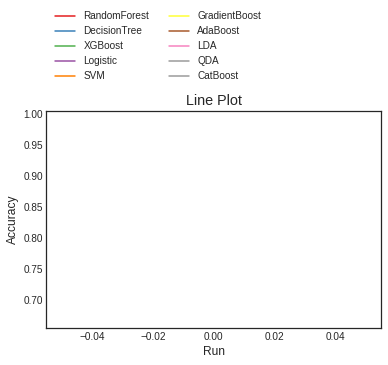

In [31]:
plt.style.use('ggplot')
plt.style.use('seaborn-white')

palette = plt.get_cmap("Set1")

for i, column in enumerate(performance_table):
    plt.plot(performance_table[column], color = palette(i), label = column)

plt.legend(loc = 2, ncol = 2, bbox_to_anchor = (0,1.5))
plt.title("Line Plot")
plt.xlabel("Run")
plt.ylabel("Accuracy")

In [32]:
performance_table.describe()

,RandomForest,DecisionTree,XGBoost,Logistic,SVM,GradientBoost,AdaBoost,LDA,QDA,CatBoost
count,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000
mean,0.988827,0.988827,0.977654,0.977654,0.670391,0.988827,0.977654,0.988827,0.871508,0.98324
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.988827,0.988827,0.977654,0.977654,0.670391,0.988827,0.977654,0.988827,0.871508,0.98324
25%,0.988827,0.988827,0.977654,0.977654,0.670391,0.988827,0.977654,0.988827,0.871508,0.98324
50%,0.988827,0.988827,0.977654,0.977654,0.670391,0.988827,0.977654,0.988827,0.871508,0.98324
75%,0.988827,0.988827,0.977654,0.977654,0.670391,0.988827,0.977654,0.988827,0.871508,0.98324
max,0.988827,0.988827,0.977654,0.977654,0.670391,0.988827,0.977654,0.988827,0.871508,0.98324


Text(0, 0.5, 'Accuracy')

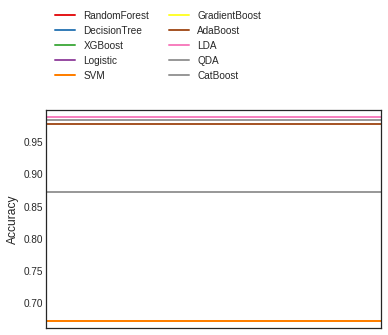

In [33]:
df = performance_table.describe()
mean_list = list(df.loc["mean", :])

palette = plt.get_cmap("Set1")

for i, mean in enumerate(mean_list):
    plt.axhline(y = mean, color = palette(i), label = models[i], linewidth = 2)
    
plt.legend(loc = 2, ncol = 2, bbox_to_anchor = (0,1.5))
plt.xticks([])
plt.ylim(min(mean_list) - 0.01, max(mean_list) + 0.01)
plt.ylabel("Accuracy")    

In [34]:
classifier = CatBoostClassifier()
classifier.fit(train_data, train_labels.values.ravel())
prediction = classifier.predict(test_data)

Learning rate set to 0.016216
0:	learn: 0.6543241	total: 16.8ms	remaining: 16.8s
1:	learn: 0.6249079	total: 33.8ms	remaining: 16.9s
2:	learn: 0.5914229	total: 50.4ms	remaining: 16.8s
3:	learn: 0.5598377	total: 66.4ms	remaining: 16.5s
4:	learn: 0.5283060	total: 82.4ms	remaining: 16.4s
5:	learn: 0.4991918	total: 99ms	remaining: 16.4s
6:	learn: 0.4688431	total: 115ms	remaining: 16.4s
7:	learn: 0.4438045	total: 128ms	remaining: 15.9s
8:	learn: 0.4250520	total: 144ms	remaining: 15.9s
9:	learn: 0.4022087	total: 161ms	remaining: 15.9s
10:	learn: 0.3810689	total: 177ms	remaining: 15.9s
11:	learn: 0.3623661	total: 193ms	remaining: 15.9s
12:	learn: 0.3443825	total: 213ms	remaining: 16.2s
13:	learn: 0.3302468	total: 225ms	remaining: 15.9s
14:	learn: 0.3133593	total: 243ms	remaining: 15.9s
15:	learn: 0.2954490	total: 259ms	remaining: 15.9s
16:	learn: 0.2809815	total: 271ms	remaining: 15.7s
17:	learn: 0.2688836	total: 287ms	remaining: 15.6s
18:	learn: 0.2571010	total: 299ms	remaining: 15.5s
19:	lea

In [35]:
submit = pd.DataFrame(list(zip(submission["PassengerId"], prediction)), columns = ["PassengerId", "Survived"])
submit["Survived"] = submit["Survived"].map({
    1.0 : 1,
    0.0 : 0,
})
submit.to_csv("submit.csv", index = False)